<a href="https://colab.research.google.com/github/aayushkhanna09/ml-lab/blob/main/ml7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



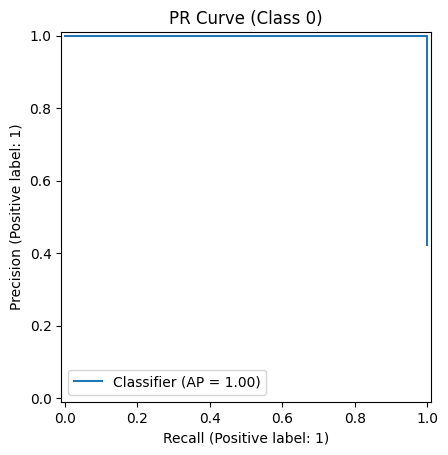

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize

# 1) Load the dataset and split it [cite: 3]
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2) Train Random Forest with varying hyperparameters [cite: 4]
rf = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
rf.fit(X_train, y_train)

# 3) Predict class labels [cite: 6]
y_pred = rf.predict(X_test)

# 4) Evaluate the model [cite: 7]
print("Accuracy:", accuracy_score(y_test, y_pred)) # [cite: 8]
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)) # [cite: 9]
print("Classification Report:\n", classification_report(y_test, y_pred)) # [cite: 10]

# Precision-Recall Curve (Simplified for Class 0 vs Rest) [cite: 11]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = rf.predict_proba(X_test)
PrecisionRecallDisplay.from_predictions(y_test_bin[:, 0], y_score[:, 0])
plt.title("PR Curve (Class 0)")
plt.show()

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



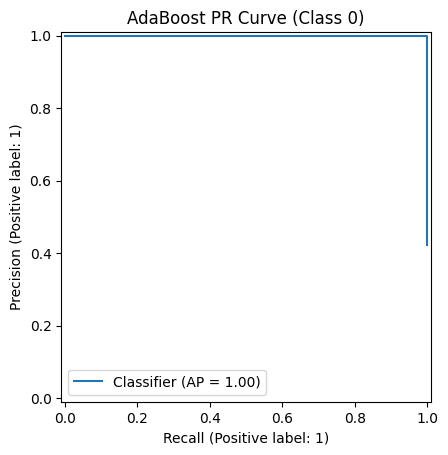

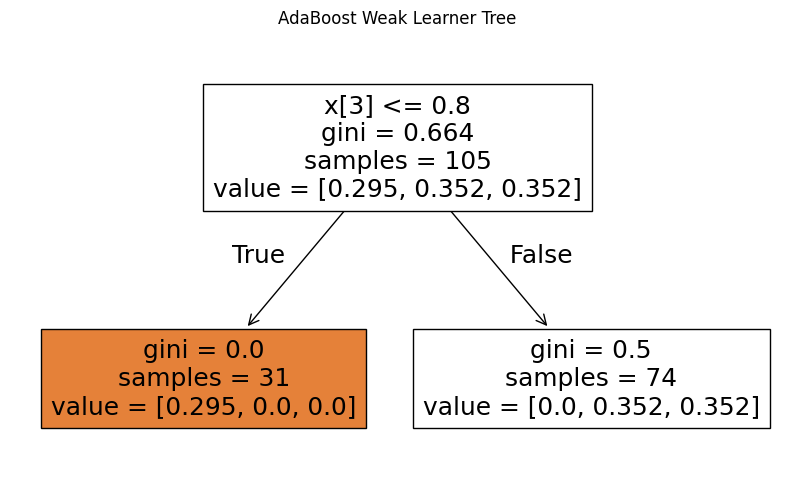

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1) Train AdaBoost investigating weak learners and learning rate [cite: 13, 14]
base_est = DecisionTreeClassifier(max_depth=1)
ada = AdaBoostClassifier(estimator=base_est, n_estimators=50, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

# 2) Predict class labels [cite: 15]
y_pred_ada = ada.predict(X_test)

# 3) Evaluate the model [cite: 16]
print("Accuracy:", accuracy_score(y_test, y_pred_ada)) # [cite: 17]
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada)) # [cite: 18]
print("Classification Report:\n", classification_report(y_test, y_pred_ada)) # [cite: 19]

# Precision-Recall Curve [cite: 20]
y_score_ada = ada.predict_proba(X_test)
PrecisionRecallDisplay.from_predictions(y_test_bin[:, 0], y_score_ada[:, 0])
plt.title("AdaBoost PR Curve (Class 0)")
plt.show()

# Visualize the decision tree (First weak learner) [cite: 21]
plt.figure(figsize=(10,6))
plot_tree(ada.estimators_[0], filled=True)
plt.title("AdaBoost Weak Learner Tree")
plt.show()